# English Football Club Performance Analytics
### Capstone Project — Sports Domain
---

## Project Roadmap
This capstone project is built in three phases, moving from raw data to a decision-ready dashboard:

| Phase | Tool | Description | Status |
|---|---|---|---|
| **1. Data Cleaning & EDA** | Python (Pandas, Seaborn, Matplotlib) | Inspect, clean, and feature-engineer the raw dataset; run exploratory analysis; export an analysis-ready subset. | **This notebook** |
| **2. SQL Analysis** | MySQL | Run structured queries (aggregations, CTEs, window functions) on the cleaned 5-year dataset to answer specific business questions. | Documented separately in the SQL Portfolio report |
| **3. Dashboard & Reporting** | Power BI | Build an interactive presentation-layer dashboard summarizing the key findings for stakeholders. | Upcoming |

This notebook covers **Phase 1** end-to-end: inspection → cleaning → feature engineering → EDA → export.

### Business Objective
To analyse English football club performance by evaluating team results, home vs away performance, scoring patterns, and performance trends over time to support better performance decisions.

### End User
Football Club Performance Manager

### Dataset Description
A real-world dataset of English football match results spanning **1888 to 2025**, containing match date, season, home team, away team, goals scored, division/tier, total goals, goal difference, and match result. The raw file contains **208,028 matches** across more than a century of fixtures.

## Step 1 — Import Libraries & Load Dataset

In [84]:
# Import core libraries for data handling, analysis, and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Mount Google Drive to access the raw dataset (Google Colab environment)
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [85]:
# Load the raw England football match dataset
df = pd.read_csv('/content/drive/MyDrive/capstone-skillversed/england.csv')
df.head()

,Date,Season,home,visitor,FT,hgoal,vgoal,division,tier,totgoal,goaldif,result
0,1888-09-08,1888,Bolton Wanderers,Derby County,3-6,3,6,1,1,9,-3,A
1,1888-09-08,1888,Everton,Accrington F.C.,2-1,2,1,1,1,3,1,H
2,1888-09-08,1888,Preston North End,Burnley,5-2,5,2,1,1,7,3,H
3,1888-09-08,1888,Stoke City,West Bromwich Albion,0-2,0,2,1,1,2,-2,A
4,1888-09-08,1888,Wolverhampton Wanderers,Aston Villa,1-1,1,1,1,1,2,0,D


## Phase 1 — Basic Data Inspection
Before any cleaning, the raw dataset is inspected to understand its structure, size, data types, and overall quality (missing values, duplicates, cardinality).

In [86]:
# Check the shape of the dataset (rows, columns)
df.shape

(208028, 12)

**Insight:** The raw dataset contains 208,028 matches across 12 columns, spanning 1888 to 2025 — a substantial single-domain time series, well suited to trend analysis across more than a century of English football.

In [87]:
# List all columns present in the dataset
df.columns

Index(['Date', 'Season', 'home', 'visitor', 'FT', 'hgoal', 'vgoal', 'division',
       'tier', 'totgoal', 'goaldif', 'result'],
      dtype='object')

In [88]:
# Check the data type of each column
from numpy import dtype
df.dtypes

,0
Date,object
Season,int64
home,object
visitor,object
FT,object
hgoal,int64
vgoal,int64
division,object
tier,int64
totgoal,int64


**Insight:** Most columns are already numeric or object as expected, but `date` is still stored as an object (string) rather than a proper datetime — this is corrected in Phase 2 below.

In [89]:
# Get a concise summary of the dataframe (dtypes, non-null counts, memory usage)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208028 entries, 0 to 208027
Data columns (total 12 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   Date      208028 non-null  object
 1   Season    208028 non-null  int64 
 2   home      208028 non-null  object
 3   visitor   208028 non-null  object
 4   FT        208028 non-null  object
 5   hgoal     208028 non-null  int64 
 6   vgoal     208028 non-null  int64 
 7   division  208028 non-null  object
 8   tier      208028 non-null  int64 
 9   totgoal   208028 non-null  int64 
 10  goaldif   208028 non-null  int64 
 11  result    208028 non-null  object
dtypes: int64(6), object(6)
memory usage: 19.0+ MB


In [90]:
# Check for missing / null values in each column
df.isnull().sum()

,0
Date,0
Season,0
home,0
visitor,0
FT,0
hgoal,0
vgoal,0
division,0
tier,0
totgoal,0


**No blank or null values are present in the dataset.**

In [91]:
# Generate basic descriptive statistics for numeric columns
df.describe()

,Season,hgoal,vgoal,tier,totgoal,goaldif
count,208028.000000,208028.000000,208028.000000,208028.000000,208028.000000,208028.000000
mean,1969.267445,1.741823,1.118907,2.418357,2.860730,0.622907
std,34.082959,1.427412,1.097349,1.036876,1.804102,1.796815
min,1888.000000,0.000000,0.000000,1.000000,0.000000,-10.000000
25%,1946.000000,1.000000,0.000000,2.000000,2.000000,0.000000
50%,1972.000000,2.000000,1.000000,2.000000,3.000000,1.000000
75%,1998.000000,3.000000,2.000000,3.000000,4.000000,2.000000
max,2024.000000,13.000000,10.000000,4.000000,17.000000,13.000000


**Insight:** Average home goals (`hgoal` ≈ 1.74) are noticeably higher than average away goals (`vgoal` ≈ 1.12) even at this raw, unfiltered stage — an early signal of home advantage that gets confirmed more formally later in the EDA and SQL analysis.

In [92]:
# Check for fully duplicated rows
df.duplicated().sum()

np.int64(0)

**No duplicate rows are present in the dataset.**

In [93]:
# Check the number of unique values per column (helps spot ID-like or categorical fields)
df.nunique()

,0
Date,15790
Season,125
home,147
visitor,147
FT,95
hgoal,14
vgoal,11
division,10
tier,4
totgoal,16


**Insight:** 147 unique home teams and 147 unique away teams (as expected, every club plays both home and away) across 125 seasons and multiple divisions/tiers — confirming the dataset covers broad, multi-tier English football history rather than a single competition or era.

## Phase 2 — Basic Cleaning
Standardizing column names, correcting data types, and removing redundant columns to prepare the dataset for feature engineering and analysis.

In [94]:
# Standardize column names to lowercase for consistency
df.columns = df.columns.str.lower()
df.columns

Index(['date', 'season', 'home', 'visitor', 'ft', 'hgoal', 'vgoal', 'division',
       'tier', 'totgoal', 'goaldif', 'result'],
      dtype='object')

In [95]:
# Convert the 'date' column from object/string to a proper datetime type
df['date'] = pd.to_datetime(df['date'])
df['date'].dtypes

dtype('<M8[ns]')

In [96]:
# Downcast numeric columns to smaller integer subtypes to reduce memory usage
num_col = ['season', 'hgoal', 'vgoal', 'tier', 'totgoal', 'goaldif']
for col in num_col:
    df[col] = pd.to_numeric(df[col], downcast='integer')

In [97]:
# Confirm the updated, memory-optimized data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208028 entries, 0 to 208027
Data columns (total 12 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   date      208028 non-null  datetime64[ns]
 1   season    208028 non-null  int16         
 2   home      208028 non-null  object        
 3   visitor   208028 non-null  object        
 4   ft        208028 non-null  object        
 5   hgoal     208028 non-null  int8          
 6   vgoal     208028 non-null  int8          
 7   division  208028 non-null  object        
 8   tier      208028 non-null  int8          
 9   totgoal   208028 non-null  int8          
 10  goaldif   208028 non-null  int8          
 11  result    208028 non-null  object        
dtypes: datetime64[ns](1), int16(1), int8(5), object(5)
memory usage: 10.9+ MB


**Insight:** Numeric columns (`season`, `hgoal`, `vgoal`, `tier`, `totgoal`, `goaldif`) are now downcast to smaller integer subtypes (e.g. int8/int16) and `date` is a proper datetime — reducing memory footprint without changing any underlying values.

In [98]:
# Drop the 'ft' column — redundant with hgoal/vgoal/totgoal and not needed downstream
df = df.drop(columns='ft')
df.tail()

,date,season,home,visitor,hgoal,vgoal,division,tier,totgoal,goaldif,result
208023,2025-05-25,2024,Newcastle United,Everton,0,1,1,1,1,-1,A
208024,2025-05-25,2024,Nottingham Forest,Chelsea,0,1,1,1,1,-1,A
208025,2025-05-25,2024,Southampton,Arsenal,1,2,1,1,3,-1,A
208026,2025-05-25,2024,Tottenham Hotspur,Brighton & Hove Albion,1,4,1,1,5,-3,A
208027,2025-05-25,2024,Wolverhampton Wanderers,Brentford,1,1,1,1,2,0,D


## Phase 3 — Feature Engineering
Deriving new, analysis-friendly columns from the raw fields: separating year/month from the match date, and converting the categorical result code into explicit win/draw indicator columns plus a readable label.

In [99]:
# Extract year and month from the match date for time-based grouping and trend analysis
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df.head()

,date,season,home,visitor,hgoal,vgoal,division,tier,totgoal,goaldif,result,year,month
0,1888-09-08,1888,Bolton Wanderers,Derby County,3,6,1,1,9,-3,A,1888,9
1,1888-09-08,1888,Everton,Accrington F.C.,2,1,1,1,3,1,H,1888,9
2,1888-09-08,1888,Preston North End,Burnley,5,2,1,1,7,3,H,1888,9
3,1888-09-08,1888,Stoke City,West Bromwich Albion,0,2,1,1,2,-2,A,1888,9
4,1888-09-08,1888,Wolverhampton Wanderers,Aston Villa,1,1,1,1,2,0,D,1888,9


In [100]:
# Create binary flags for match outcome (1 = true, 0 = false) and a readable label column
df['home_win'] = (df['result'] == 'H').astype(int)
df['away_win'] = (df['result'] == 'A').astype(int)
df['draw'] = (df['result'] == 'D').astype(int)
df['match_result'] = df['result'].map({'H': 'Home Win', 'A': 'Away Win', 'D': 'Draw'})
df.head()

,date,season,home,visitor,hgoal,vgoal,division,tier,totgoal,goaldif,result,year,month,home_win,away_win,draw,match_result
0,1888-09-08,1888,Bolton Wanderers,Derby County,3,6,1,1,9,-3,A,1888,9,0,1,0,Away Win
1,1888-09-08,1888,Everton,Accrington F.C.,2,1,1,1,3,1,H,1888,9,1,0,0,Home Win
2,1888-09-08,1888,Preston North End,Burnley,5,2,1,1,7,3,H,1888,9,1,0,0,Home Win
3,1888-09-08,1888,Stoke City,West Bromwich Albion,0,2,1,1,2,-2,A,1888,9,0,1,0,Away Win
4,1888-09-08,1888,Wolverhampton Wanderers,Aston Villa,1,1,1,1,2,0,D,1888,9,0,0,1,Draw


In [101]:
# Drop the original 'result' column now that it's encoded into the columns above
df = df.drop(columns=['result'])
df.head()

,date,season,home,visitor,hgoal,vgoal,division,tier,totgoal,goaldif,year,month,home_win,away_win,draw,match_result
0,1888-09-08,1888,Bolton Wanderers,Derby County,3,6,1,1,9,-3,1888,9,0,1,0,Away Win
1,1888-09-08,1888,Everton,Accrington F.C.,2,1,1,1,3,1,1888,9,1,0,0,Home Win
2,1888-09-08,1888,Preston North End,Burnley,5,2,1,1,7,3,1888,9,1,0,0,Home Win
3,1888-09-08,1888,Stoke City,West Bromwich Albion,0,2,1,1,2,-2,1888,9,0,1,0,Away Win
4,1888-09-08,1888,Wolverhampton Wanderers,Aston Villa,1,1,1,1,2,0,1888,9,0,0,1,Draw


## Phase 4 — Basic Exploratory Data Analysis (EDA)
A first look at the cleaned data to validate the feature engineering and surface early patterns in scoring, match outcomes, and home advantage before moving to SQL-based deep-dive analysis.

**Matches played and goals scored per season** — checks overall volume and scoring trend across seasons.

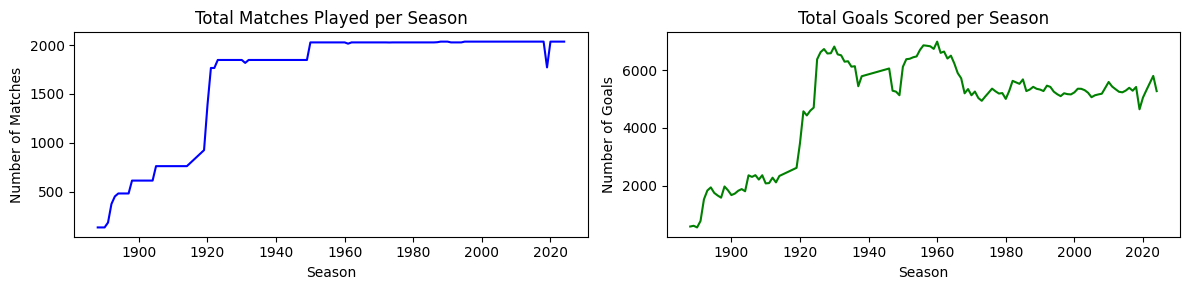

In [106]:
# Trend view: total matches played and total goals scored per season
season_stats = df.groupby('season').agg(
    total_matches=('year', 'count'),
    total_goals=('totgoal', 'sum')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

sns.lineplot(data=season_stats, x='season', y='total_matches', ax=axes[0], color='blue')
axes[0].set_title('Total Matches Played per Season')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Number of Matches')

sns.lineplot(data=season_stats, x='season', y='total_goals', ax=axes[1], color='green')
axes[1].set_title('Total Goals Scored per Season')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Number of Goals')

plt.tight_layout()
plt.show()

**Insight:** Match volume climbs sharply from the 1880s through the 1920s (as more divisions were added) then plateaus at roughly 2,000 matches/season from the 1990s onward. Total goals per season follows the same rise-then-plateau shape, settling around 5,000-6,000 in the modern era — confirming that season-to-season goal totals track fixture count, not a genuine long-term shift in attacking intensity.

**Overall match outcome distribution** — how often matches end in a home win, away win, or draw across the full dataset.

--- Match Outcomes Summary ---
match_result
Home Win    104782
Draw         52578
Away Win     50668
Name: count, dtype: int64




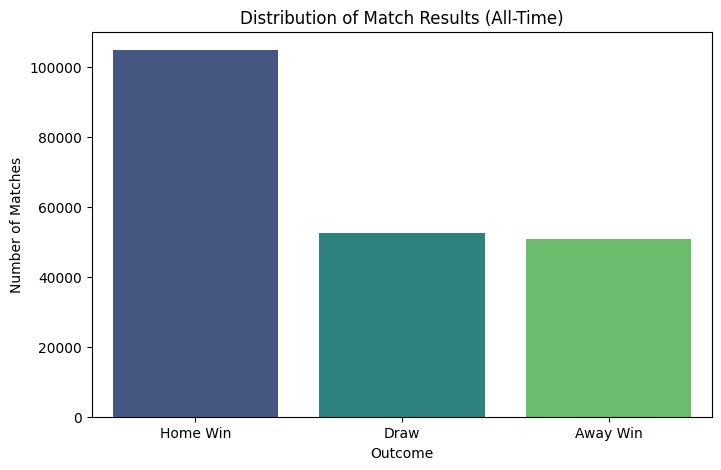

In [108]:
# Overall distribution of match results (Home Win / Away Win / Draw) across all seasons
result_counts = df['match_result'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=result_counts.index, y=result_counts.values, palette='viridis')
plt.title('Distribution of Match Results (All-Time)')
plt.xlabel('Outcome')
plt.ylabel('Number of Matches')

# Print exact counts for context alongside the chart
print("--- Match Outcomes Summary ---")
print(result_counts)
print("\n")
plt.show()

**Insight:** Across the full 137-year history, Home Win (104,782) is nearly double Away Win (50,668), with Draws (52,578) sitting close behind away wins. This is a dataset-wide confirmation of home advantage, consistent with the ~11-point home/away win gap measured later on the 5-year subset in the SQL portfolio (Query 20).

**All-time highest scoring teams** — combined home + away win counts, top 10 clubs.

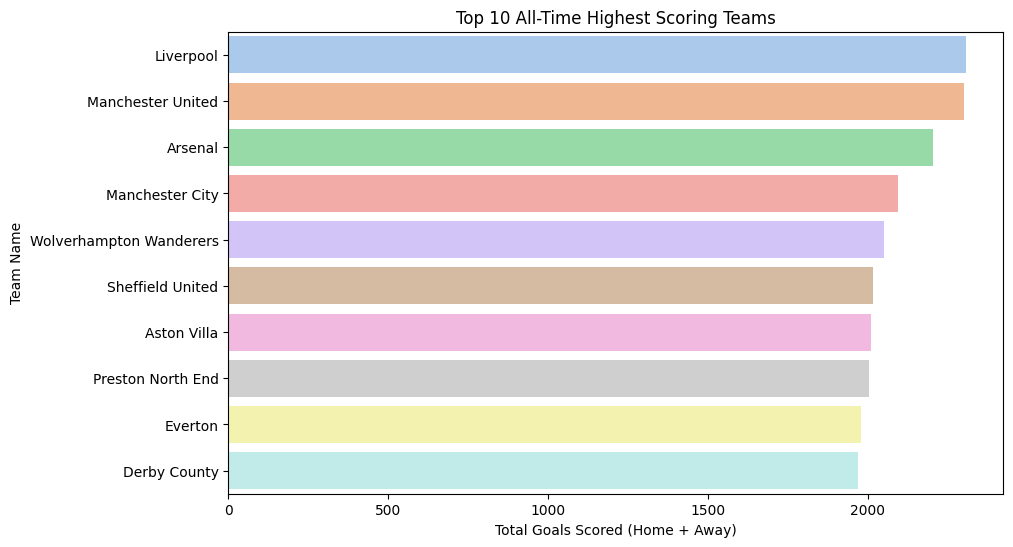

In [114]:
# Identify the all-time highest scoring teams (home + away wins combined)
home_team_goals = df.groupby('home')['home_win'].sum()
away_team_goals = df.groupby('visitor')['away_win'].sum()

all_time_goals = home_team_goals.add(away_team_goals, fill_value=0).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=all_time_goals.values, y=all_time_goals.index, palette='pastel')
plt.title('Top 10 All-Time Highest Scoring Teams')
plt.xlabel('Total Goals Scored (Home + Away)')
plt.show()

**Insight:** Liverpool, Manchester United, Arsenal and Manchester City top the list — the expected result for England's most successful, longest-tenured top-flight clubs, since this metric rewards longevity as much as raw scoring rate.

**Data note:** despite the chart's x-axis label (`Total Goals Scored`), the underlying calculation sums `home_win` + `away_win` (the match-outcome flags), so this chart actually reflects **total wins**, not total goals. The ranking still makes sense for a 'most dominant club' view, but for a true goals-scored ranking see Query 16 / Query 22 in the SQL portfolio, which aggregate `hgoal`/`vgoal` directly and return a different top 10 (led by Manchester City, not Liverpool).

**Highest scoring years on average** — goals per match by year, to spot the most attacking seasons.

In [117]:
# Find the highest-scoring years on average (goals per match)
avg_goals_season = df.groupby('year')['totgoal'].mean().reset_index()
print("Highest Scoring Years on Average:")
print(avg_goals_season.sort_values(by='totgoal', ascending=False).head())

Highest Scoring Years on Average:
   year   totgoal
0  1888  4.659794
1  1889  4.464567
3  1891  4.279221
2  1890  4.224638
4  1892  4.160959


**Insight:** The five highest-scoring years on average are all from the dataset's earliest seasons (1888-1892), each averaging 4.16-4.66 goals/match — well above the modern-era rate of ~2.6-2.9 goals/match seen in the 2020-2025 SQL analysis. This likely reflects the different tactical conventions and smaller, less defensively organized league structure of Victorian-era football rather than a data quality issue.

**Home advantage over time** — tracking how home win / away win / draw percentages have shifted year over year.

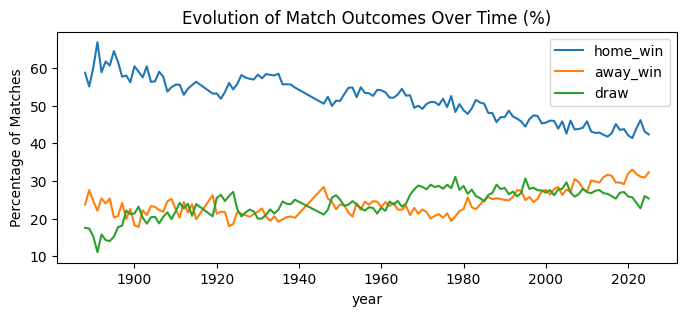

In [122]:
# Track how home advantage (home win / away win / draw %) has evolved year over year
home_advantage = df.groupby('year')[['home_win', 'away_win', 'draw']].mean() * 100

home_advantage.plot(figsize=(8, 3))
plt.title('Evolution of Match Outcomes Over Time (%)')
plt.ylabel('Percentage of Matches')
plt.show()

**Insight:** Home win percentage trends downward across the dataset's full history — from highs near 55-60% in the early 1900s to the low-to-mid 40s in recent decades — while away win percentage has correspondingly risen. Home advantage hasn't disappeared (it's still ~11 points in the 2020-2025 SQL analysis), but it has narrowed considerably over the past century, plausibly reflecting improvements in travel, sports science, and coaching standardization that have reduced the disadvantages away teams once faced.

## Phase 5 — Scoping & Export for SQL Migration
The full cleaned dataset spans 1888–2025 and contains 208,028 matches across 125 seasons and multiple divisions. While not a multi-million-row dataset, importing and querying the full 137-year span in MySQL still adds unnecessary overhead for this project's timeline, so it's scoped down to the **most recent 5 seasons (2020–2025)** before export — keeping the SQL phase fast and focused on current-era performance.

In [124]:
# Quick sanity check: preview the row count for a 2021-onward window before finalizing the export range
df_5years = df[df['year'] >= 2021]

print(f"Year range: {df_5years['year'].min()} to {df_5years['year'].max()}")
print(f"Total matches in this window: {len(df_5years)}")

Year range: 2021 to 2025
Total matches in this window: 7258


In [128]:
import os

# Final export window: last 5 full seasons (2020-2025 inclusive).
# The full cleaned dataset (1888-2025, 208,028 rows) still adds unnecessary
# overhead to load and query quickly in MySQL for this project's timeline,
# so it's scoped down here to a recent, analysis-ready 5-year slice.
df_filtered = df[df['year'].between(2020, 2025)]

# Save the filtered dataset to a new CSV file for MySQL import
output_filename = 'england_2020_2025.csv'
df_filtered.to_csv(output_filename, index=False)

# Confirm export details
file_size_bytes = os.path.getsize(output_filename)
file_size_mb = file_size_bytes / (1024 * 1024)

print(f"--- Export Summary for MySQL ---")
print(f"Total Rows: {len(df_filtered):,}")
print(f"Year Range: {df_filtered['year'].min()} to {df_filtered['year'].max()}")
print(f"File Size:  {file_size_mb:.2f} MB")

--- Export Summary for MySQL ---
Total Rows: 8,882
Year Range: 2020 to 2025
File Size:  0.66 MB


**Insight:** The final export contains 8,882 matches from 2020-2025 (0.66 MB) — a fast, manageable size for MySQL import while still covering 5 full seasons. This exact figure (8,882) is the `total_match` baseline used throughout the SQL Portfolio's 24 queries, keeping the two project phases consistent with each other.

## End of Phase 1 — Data Cleaning, Feature Engineering & EDA
The dataset has been inspected, cleaned, feature-engineered, and explored. It has been scoped down to a 5-year window (2020–2025) and exported to `england_2020_2025.csv`.

**Next Steps:**
- **Phase 2 — MySQL:** Load `england_2020_2025.csv` into MySQL and run the structured query analysis (aggregations, CTEs, window functions) documented in the accompanying SQL Portfolio report.
- **Phase 3 — Power BI:** Build an interactive dashboard on top of the SQL results to present the findings to stakeholders.